In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler


import matplotlib.pyplot as plt
import random
import time
import seaborn as sns

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

#Supress Warnings
import warnings
warnings.filterwarnings('ignore')

import gc

# Allow TF to grow GPU memory as needed (prevents pre-allocating the full GPU)
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"Could not set memory growth: {e}")


I0000 00:00:1776220464.552200  592534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776220465.156213  592534 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# load
d = np.load("processed_waveforms.npz")
 # ["X_euclidean"] or ["X_voltage"]
X = d["X_voltage"].astype(np.float32)
# 0=photon, 1=neutron
y = d["y"].astype(np.int32)

# 60/20/20 train/val/test split
# First split off 20% test
X_trainval, X_test, Y_trainval, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# Then split remaining 80% into 60% train + 20% val (0.25 of 80% = 20% of total)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_trainval, Y_trainval, test_size=0.25, random_state=42, stratify=Y_trainval)

# Min-max scale to [0, 1] using only training statistics
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

latent_dim = 16
input_length = X_train.shape[1]

#  Encoder 
inputs = tf.keras.Input(shape=(input_length, 1))
x = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling1D(2, padding='same')(x)
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2, padding='same')(x)
shape = x.shape[1:]

# Feature vector
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, name="latent")(x) #Flatten into latent dimension

#  Decoder (input is feature vector) 
x = layers.Dense(shape[0] * shape[1], activation='relu')(latent)
x = layers.Reshape(shape)(x)
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling1D(2)(x)
x = layers.Conv1D(32, 3, activation='relu', padding='same')(x)

#Reconstructed Signal
reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

#  Classifier 
clf = layers.Dense(32, activation='relu')(latent)
#clf = layers.Dense(16, activation='relu')(clf)
classification = layers.Dense(1, activation='sigmoid', name="classification")(clf)

# Full Model
model = Model(inputs, [reconstruction, classification])

X_test_n = X_test
X_train_n = X_train

I0000 00:00:1776220466.922132  592534 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12197 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [3]:
model.compile(
    optimizer='adam',
    loss={
        'reconstruction': 'mse',
        'classification': 'binary_crossentropy'},
    loss_weights={
        'reconstruction': 30.0,
        'classification': 1.0},
    metrics={
        'classification': ['accuracy']})


In [4]:
early_stop_initial = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode='min'
)

initial_history = model.fit(
    X_train,
    {
        "reconstruction": X_train,
        "classification": Y_train},
    validation_data=(
        X_val,
        {
            "reconstruction": X_val,
            "classification": Y_val}
    ),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_initial]
)

Epoch 1/100


I0000 00:00:1776220468.493675  592685 service.cc:153] XLA service 0x7c0c5c039500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776220468.493690  592685 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1776220468.524810  592685 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776220468.740531  592685 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1776220468.750475  592685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4668__.46
I0000 00:00:1776220469.174983  592842 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads



  65/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - classification_accuracy: 0.5385 - classification_loss: 0.6894 - loss: 1.0652 - reconstruction_loss: 0.0125

I0000 00:00:1776220471.078353  592685 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1214/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - classification_accuracy: 0.8846 - classification_loss: 0.2131 - loss: 0.2840 - reconstruction_loss: 0.0024

I0000 00:00:1776220474.126398  592685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4668__.46
E0000 00:00:1776220474.742853  593293 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776220474.905959  593294 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776220475.008616  593289 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776220475.123279  593303 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1219/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - classification_accuracy: 0.8849 - classification_loss: 0.2126 - loss: 0.2833 - reconstruction_loss: 0.0024

I0000 00:00:1776220476.646688  592685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12626__.14
I0000 00:00:1776220477.415059  592694 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12626__.14


1219/1219 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - classification_accuracy: 0.9603 - classification_loss: 0.0822 - loss: 0.1130 - reconstruction_loss: 0.0010 - val_classification_accuracy: 0.9916 - val_classification_loss: 0.0211 - val_loss: 0.0387 - val_reconstruction_loss: 5.8543e-04
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - classification_accuracy: 0.9898 - classification_loss: 0.0247 - loss: 0.0418 - reconstruction_loss: 5.6895e-04 - val_classification_accuracy: 0.9791 - val_classification_loss: 0.0557 - val_loss: 0.0723 - val_reconstruction_loss: 5.5304e-04
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - classification_accuracy: 0.9908 - classification_loss: 0.0222 - loss: 0.0383 - reconstruction_loss: 5.3626e-04 - val_classification_accuracy: 0.9925 - val_classification_loss: 0.0183 - val_loss: 0.0341 - val_reconstruction_loss: 5.2557e-04
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - classification_accuracy: 0.9917 - classification_loss: 0.0204 - los

I0000 00:00:1776220539.220682  592695 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_202077__.7


3172/3251 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step

I0000 00:00:1776220540.873437  592685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_212134__.7


3251/3251 ━━━━━━━━━━━━━━━━━━━━ 2s 509us/step


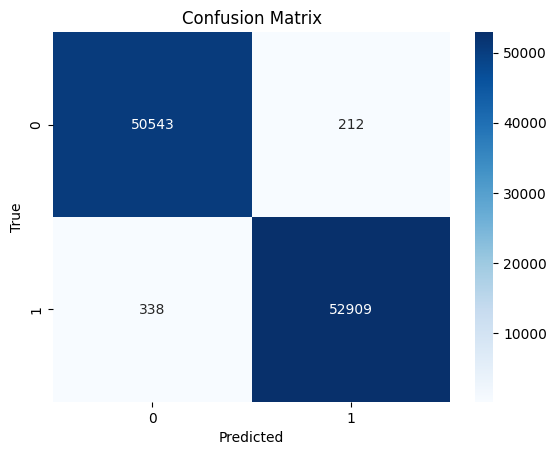

In [5]:
# Get predictions
y_pred = model.predict(X_test_n)[1]

# Convert probabilities from sigmoid to binary
y_pred_bin = (y_pred > 0.5).astype(int)

# Plot confusion matrix for each label
cm = confusion_matrix(Y_test, y_pred_bin)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

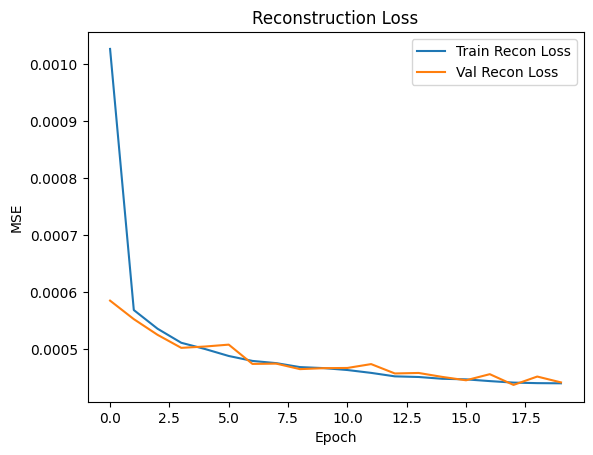

In [6]:
plt.figure()
plt.plot(initial_history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(initial_history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

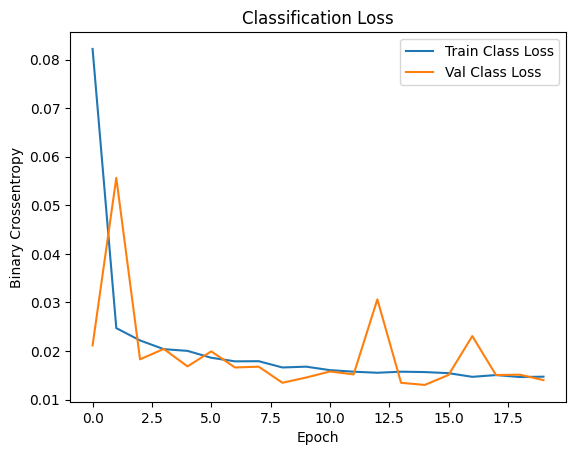

In [7]:
plt.figure()
plt.plot(initial_history.history['classification_loss'], label='Train Class Loss')
plt.plot(initial_history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

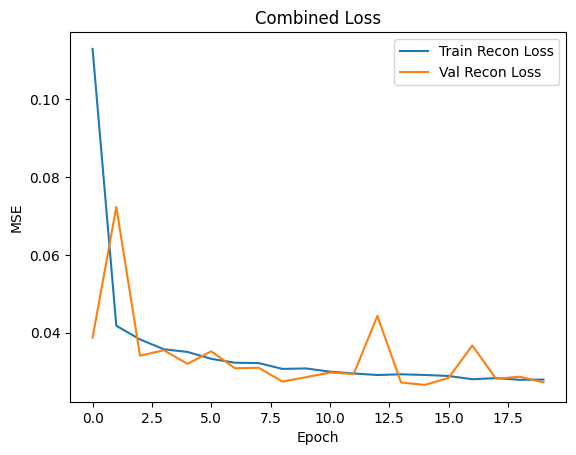

In [8]:
plt.figure()
plt.plot(initial_history.history['loss'], label='Train Recon Loss')
plt.plot(initial_history.history['val_loss'], label='Val Recon Loss')
plt.title('Combined Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [9]:
#Hyper parameter tuning 

In [10]:
def resolve_filters(conv_filters, num_layers):
    """Option A: truncate if fewer layers, extend by doubling if more."""
    f = list(conv_filters)
    if num_layers <= len(f):
        return tuple(f[:num_layers])
    while len(f) < num_layers:
        f.append(f[-1] * 2)
    return tuple(f)


def build_model(latent_dim=8,
                conv_filters=(32, 64, 128),
                dense_units=32,
                lr=1e-3,
                num_layers=3):

    filters = resolve_filters(conv_filters, num_layers)

    inputs = tf.keras.Input(shape=(input_length, 1))

    # Encoder: num_layers Conv1D + MaxPool blocks
    x = inputs
    for f in filters:
        x = layers.Conv1D(f, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2, padding='same')(x)

    shape = x.shape[1:]

    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name="latent")(x)

    # Decoder: mirror encoder (UpSampling + Conv1D), filters reversed
    x = layers.Dense(shape[0] * shape[1], activation='relu')(latent)
    x = layers.Reshape(shape)(x)
    for f in reversed(filters):
        x = layers.UpSampling1D(2)(x)
        x = layers.Conv1D(f, 3, activation='relu', padding='same')(x)

    # Crop decoder output to match input length (handles odd-length pooling asymmetry)
    x = layers.Lambda(lambda t: t[:, :input_length, :], output_shape=(input_length, filters[0]))(x)

    reconstruction = layers.Conv1D(1, 3, padding='same', name="reconstruction")(x)

    # Classifier head
    clf = layers.Dense(dense_units, activation='relu')(latent)
    classification = layers.Dense(1, activation='sigmoid', name="classification")(clf)

    model = Model(inputs, [reconstruction, classification])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss={
            "reconstruction": "mse",
            "classification": "binary_crossentropy"
        },
        loss_weights={"reconstruction": 30.0, "classification": 1.0},
        metrics={"classification": "accuracy"}
    )

    return model

In [11]:
import itertools

param_grid = {
    # Keep fixed at 8: 104 -> 8 follows rule of thumb
    "latent_dim":   [8],
    "conv_filters": [(16, 32, 64), (32, 64, 128), (64, 128, 256)],
    "dense_units":  [16, 32, 64, 128],
    "lr":           [1e-2, 1e-3, 1e-4],
    "num_layers":   [2, 3, 4],
}

def param_combinations():
    keys = list(param_grid.keys())
    for values in itertools.product(*param_grid.values()):
        yield dict(zip(keys, values))

all_params = list(param_combinations())
print(f"Total combinations: {len(all_params)}")

Total combinations: 108


In [12]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode = 'min'
)

In [13]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_classification_accuracy",
    save_best_only=True,
    mode='max'
)

In [14]:
import csv, os

best_score = -np.inf
best_model = None
best_params = None

results_path = "SinglesApril14_hyperparam_results.csv"
fieldnames = ["trial", "latent_dim", "conv_filters", "dense_units", "lr", "num_layers",
              "best_val_acc", "best_val_recon_loss", "best_val_loss", "epochs_run"]

# Resume logic: if CSV exists, read completed configs and recover best_score
completed_keys = set()
if os.path.exists(results_path):
    with open(results_path, newline="") as f:
        for row in csv.DictReader(f):
            key = (row["conv_filters"], int(row["dense_units"]),
                   float(row["lr"]), int(row["num_layers"]))
            completed_keys.add(key)
            acc = float(row["best_val_acc"])
            if acc > best_score:
                best_score = acc
                best_params = {
                    "latent_dim":   int(row["latent_dim"]),
                    "conv_filters": eval(row["conv_filters"]),
                    "dense_units":  int(row["dense_units"]),
                    "lr":           float(row["lr"]),
                    "num_layers":   int(row["num_layers"]),
                }
    print(f"Resuming: {len(completed_keys)} trials already done. Best so far: {best_score}")
else:
    with open(results_path, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writeheader()
    print("Starting fresh")


Resuming: 108 trials already done. Best so far: 0.9949904680252075


In [15]:
for i, params in enumerate(all_params):
    key = (str(params["conv_filters"]), params["dense_units"],
           params["lr"], params["num_layers"])
    if key in completed_keys:
        print(f"\nTrial {i+1}/{len(all_params)}: SKIP (already done) {params}")
        continue

    tf.keras.backend.clear_session()
    gc.collect()
    print(f"\nTrial {i+1}/{len(all_params)}")

    model = build_model(**params)

    history = model.fit(
        X_train,
        {"reconstruction": X_train, "classification": Y_train},
        validation_data=(X_val, {"reconstruction": X_val, "classification": Y_val}),
        epochs=100,
        batch_size=256,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    h = history.history
    val_acc = max(h["val_classification_accuracy"])

    row = {
        "trial": i + 1,
        "latent_dim": params["latent_dim"],
        "conv_filters": str(params["conv_filters"]),
        "dense_units": params["dense_units"],
        "lr": params["lr"],
        "num_layers": params["num_layers"],
        "best_val_acc": val_acc,
        "best_val_recon_loss": min(h["val_reconstruction_loss"]),
        "best_val_loss": min(h["val_loss"]),
        "epochs_run": len(h["val_loss"]),
    }
    with open(results_path, "a", newline="") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writerow(row)

    print("Params:", params)
    print("Best val acc:", val_acc)

    if val_acc > best_score:
        best_score = val_acc
        best_model = model
        best_params = params



Trial 1/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.01, 'num_layers': 2}

Trial 2/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.01, 'num_layers': 3}

Trial 3/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.01, 'num_layers': 4}

Trial 4/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.001, 'num_layers': 2}

Trial 5/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.001, 'num_layers': 3}

Trial 6/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.001, 'num_layers': 4}

Trial 7/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 16, 'lr': 0.0001, 'num_layers': 2}

Trial 8/108: SKIP (already done) {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'de

In [16]:
print("BEST SCORE:", best_score)
print("BEST PARAMS:", best_params)

BEST SCORE: 0.9949904680252075
BEST PARAMS: {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 32, 'lr': 0.001, 'num_layers': 2}


Rebuilt best model from best_params: {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 32, 'lr': 0.001, 'num_layers': 2}
Epoch 1/100


I0000 00:00:1776220543.503008  592686 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_248616__.35
I0000 00:00:1776220543.756958  597268 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 4 bytes spill stores, 4 bytes spill loads

E0000 00:00:1776220544.291707  597256 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1217/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - classification_accuracy: 0.8514 - classification_loss: 0.2720 - loss: 0.3789 - reconstruction_loss: 0.0036

I0000 00:00:1776220547.464170  592685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_248616__.35
I0000 00:00:1776220547.627096  597662 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776220547.738267  597676 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776220547.738805  597662 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 20 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776220547.823449  597665 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_12', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776220547.836852  597657 subprocess_compilat

1219/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_accuracy: 0.8515 - classification_loss: 0.2717 - loss: 0.3786 - reconstruction_loss: 0.0036

...

1219/1219 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - classification_accuracy: 0.9487 - classification_loss: 0.1067 - loss: 0.1472 - reconstruction_loss: 0.0013 - val_classification_accuracy: 0.9911 - val_classification_loss: 0.0219 - val_loss: 0.0422 - val_reconstruction_loss: 6.7733e-04
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - classification_accuracy: 0.9905 - classification_loss: 0.0234 - loss: 0.0426 - reconstruction_loss: 6.4262e-04 - val_classification_accuracy: 0.9869 - val_classification_loss: 0.0326 - val_loss: 0.0520 - val_reconstruction_loss: 6.4599e-04
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - classification_accuracy: 0.9906 - classification_loss: 0.0224 - loss: 0.0413 - reconstruction_loss: 6.3057e-04 - val_classification_accuracy: 0.9919 - val_classification_loss: 0.0190 - val_loss: 0.0376 - val_reconstruction_loss: 6.2112e-04
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - classification_accuracy: 0.9916 - classification_loss: 0.0206 - loss

I0000 00:00:1776220611.948603  592691 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_524373__.5
I0000 00:00:1776220612.144151  602184 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads



3127/3251 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step

I0000 00:00:1776220613.570810  592694 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_534362__.5
I0000 00:00:1776220613.725792  602305 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 4 bytes spill stores, 4 bytes spill loads



3251/3251 ━━━━━━━━━━━━━━━━━━━━ 2s 470us/step


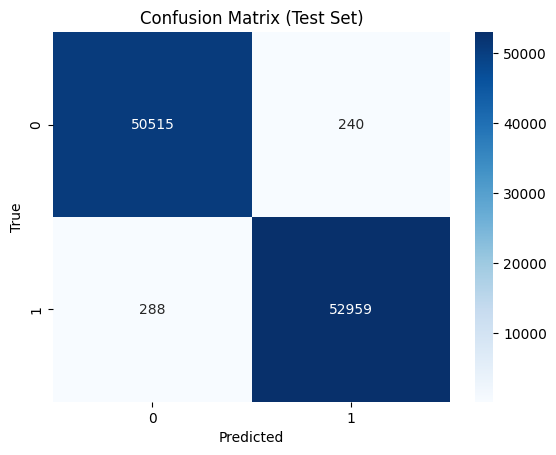

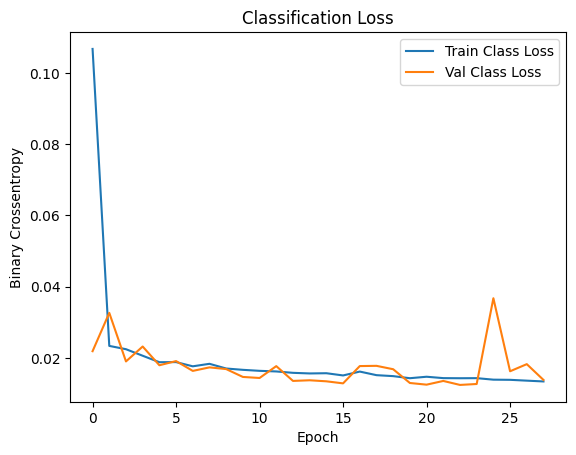

In [17]:
# Rebuild best model from best_params (avoids Lambda deserialization issue with saved .keras file)
best_model = build_model(**best_params)
print("Rebuilt best model from best_params:", best_params)

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode='min'
)

history = best_model.fit(
    X_train,
    {
        "reconstruction": X_train,
        "classification": Y_train},
    validation_data=(
        X_val,
        {
            "reconstruction": X_val,
            "classification": Y_val}
    ),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop_final]
)

# Final evaluation on held-out test set (untouched during tuning)
y_pred = best_model.predict(X_test)[1]
y_pred_bin = (y_pred > 0.5).astype(int)

cm = confusion_matrix(Y_test, y_pred_bin)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

plt.figure()
plt.plot(history.history['classification_loss'], label='Train Class Loss')
plt.plot(history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()


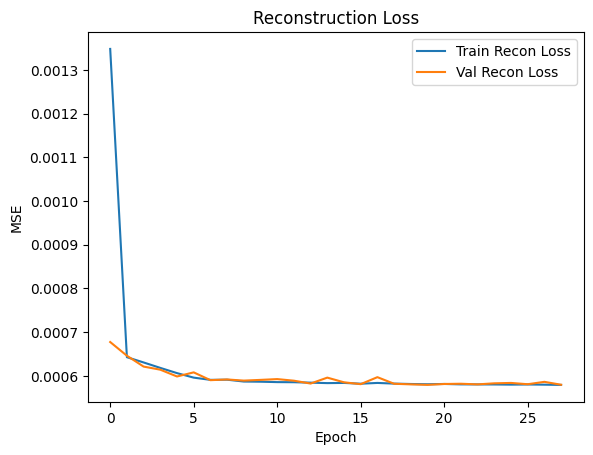

In [18]:
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

Top 1 configuration by best_val_acc:
 trial conv_filters  dense_units    lr  num_layers  best_val_acc
    13 (16, 32, 64)           32 0.001           2       0.99499

=== Training top-1 config (trial 13): {'latent_dim': 8, 'conv_filters': (16, 32, 64), 'dense_units': 32, 'lr': 0.001, 'num_layers': 2} ===
Epoch 1/100


I0000 00:00:1776220815.855140  592691 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_702990__.35


1196/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - classification_accuracy: 0.8758 - classification_loss: 0.2374 - loss: 0.3181 - reconstruction_loss: 0.0027

I0000 00:00:1776220818.854393  592686 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_702990__.35


1219/1219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - classification_accuracy: 0.8774 - classification_loss: 0.2347 - loss: 0.3144 - reconstruction_loss: 0.0027

I0000 00:00:1776220820.050256  592686 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_710864__.12
I0000 00:00:1776220820.569165  592685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_710864__.12


1219/1219 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - classification_accuracy: 0.9592 - classification_loss: 0.0904 - loss: 0.1246 - reconstruction_loss: 0.0011 - val_classification_accuracy: 0.9918 - val_classification_loss: 0.0209 - val_loss: 0.0406 - val_reconstruction_loss: 6.5776e-04
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - classification_accuracy: 0.9908 - classification_loss: 0.0226 - loss: 0.0418 - reconstruction_loss: 6.4011e-04 - val_classification_accuracy: 0.9927 - val_classification_loss: 0.0183 - val_loss: 0.0373 - val_reconstruction_loss: 6.3314e-04
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - classification_accuracy: 0.9917 - classification_loss: 0.0205 - loss: 0.0392 - reconstruction_loss: 6.2345e-04 - val_classification_accuracy: 0.9934 - val_classification_loss: 0.0171 - val_loss: 0.0357 - val_reconstruction_loss: 6.2044e-04
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - classification_accuracy: 0.9913 - classification_loss: 0.0210 - loss

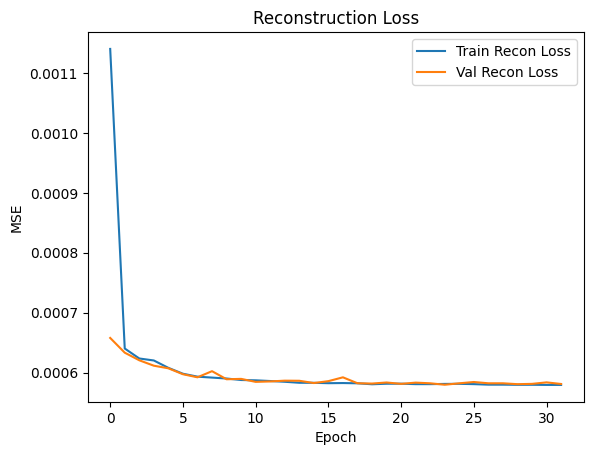

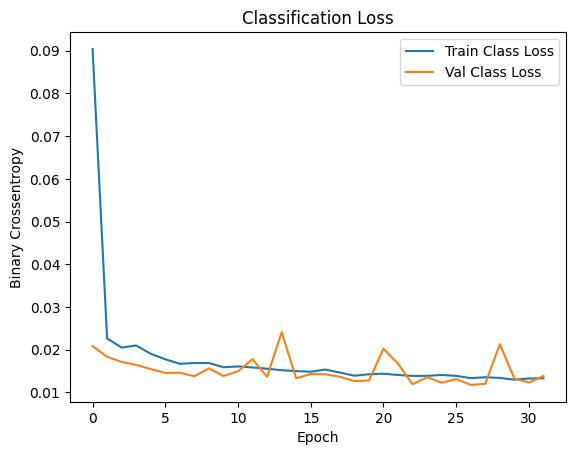

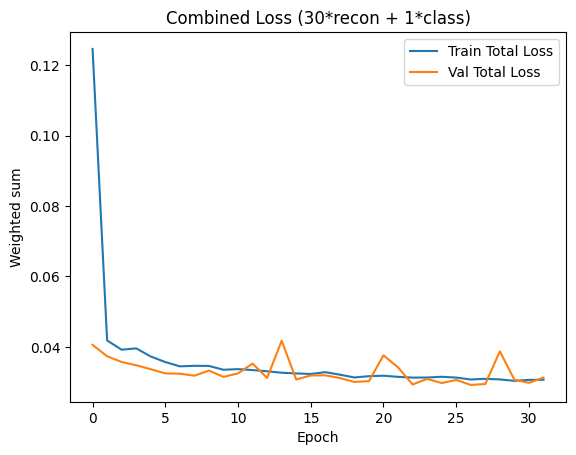

 168/3251 ━━━━━━━━━━━━━━━━━━━━ 0s 300us/step   

I0000 00:00:1776220891.322482  592686 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1018067__.5


3251/3251 ━━━━━━━━━━━━━━━━━━━━ 2s 394us/step


I0000 00:00:1776220892.601097  592685 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1028056__.5


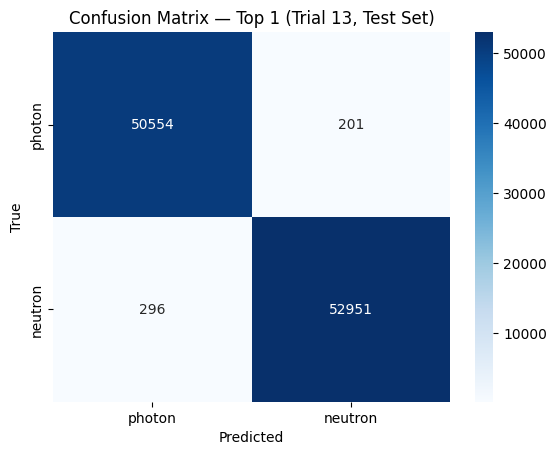

In [20]:
# Load the hyperparameter results CSV, pick top 1, retrain, plot train+val curves.
import os
import pandas as pd

os.makedirs("figures", exist_ok=True)

df = pd.read_csv("SinglesApril14_hyperparam_results.csv")
df_sorted = df.sort_values("best_val_acc", ascending=False).reset_index(drop=True)
top1 = df_sorted.head(1).copy()

print("Top 1 configuration by best_val_acc:")
print(top1[["trial", "conv_filters", "dense_units", "lr", "num_layers", "best_val_acc"]].to_string(index=False))

row = top1.iloc[0]
params = {
    "latent_dim":   int(row["latent_dim"]),
    "conv_filters": eval(row["conv_filters"]),
    "dense_units":  int(row["dense_units"]),
    "lr":           float(row["lr"]),
    "num_layers":   int(row["num_layers"]),
}

tf.keras.backend.clear_session()
gc.collect()
print(f"\n=== Training top-1 config (trial {int(row['trial'])}): {params} ===")
m = build_model(**params)
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, mode="min"
)

m.compile(
    optimizer='adam',
    loss={
        'reconstruction': 'mse',
        'classification': 'binary_crossentropy'},
    loss_weights={
        'reconstruction': 30.0,
        'classification': 1.0},
    metrics={
        'classification': ['accuracy']})

history = m.fit(
    X_train,
    {"reconstruction": X_train, "classification": Y_train},
    validation_data=(X_val, {"reconstruction": X_val, "classification": Y_val}),
    epochs=100,
    batch_size=256,
    callbacks=[es],
    verbose=1,
)



# ── Reconstruction loss ────────────────────────────────────────────────────
plt.figure()
plt.plot(history.history['reconstruction_loss'], label='Train Recon Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig("figures/singles_top1_reconstruction_loss.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Classification loss ────────────────────────────────────────────────────
plt.figure()
plt.plot(history.history['classification_loss'], label='Train Class Loss')
plt.plot(history.history['val_classification_loss'], label='Val Class Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.savefig("figures/singles_top1_classification_loss.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Combined loss ──────────────────────────────────────────────────────────
plt.figure()
plt.plot(history.history['loss'], label='Train Total Loss')
plt.plot(history.history['val_loss'], label='Val Total Loss')
plt.title('Combined Loss (30*recon + 1*class)')
plt.xlabel('Epoch')
plt.ylabel('Weighted sum')
plt.legend()
plt.savefig("figures/singles_top1_combined_loss.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Confusion matrix on held-out test set ──────────────────────────────────
y_pred = m.predict(X_test)[1]
y_pred_bin = (y_pred > 0.5).astype(int)

cm = confusion_matrix(Y_test, y_pred_bin)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["photon", "neutron"], yticklabels=["photon", "neutron"])
plt.title(f'Confusion Matrix — Top 1 (Trial {int(row["trial"])}, Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig("figures/singles_top1_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
